# Compare the preprocessing and MEIs generated if the data from the session were presented online

### generate meis with pretrained model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display



In [3]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/klaudia_data_test
  table_parameters:
    PreprocessParams:
    - preprocess_id: 1
      fs_resample: 60
      stim_names:
      - gChirp
      - lChirp
      - movingbar
      - densenoise
    - preprocess_id: 2
      window_length: 60
      poly_order: 3
      non_negative: 1
      subtract_baseline: 0
      standardize: 1
      stim_names:
      - mouse_cam
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
     

In [4]:
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper
# from simulations.loop_components.recording_file_copier import copy_rec_files,create_directory_structure
# from simulations.loop_components.stimulus import create_rf_avi_from_roi_ids, create_full_avi_from_roi_id_and_seed
# from simulations.loop_components.utils import log

In [5]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )



In [6]:


dj_table_holder.setup()


[2025-08-27 14:00:29,528][INFO]: Connecting ssuhai@172.25.240.200:3306


[2025-08-27 14:00:29,590][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop
Done reconnecting. Skipping adding new entries from config.


/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/simulations/loop_components/dj_wrappers.py:299: UserWarning: 
Some DJ tables (like UserInfo) are not empty, skipping adding new entries from config.
Make sure this is wanted. Call clear_tables(`all`) if you want different data in there
  warnings.warn("\nSome DJ tables (like UserInfo) are not empty, skipping adding new entries from config.\nMake sure this is wanted. Call clear_tables(`all`) if you want different data in there")


In [ ]:
#dj_table_holder.clear_tables("rois")

[2025-08-27 10:15:34,148][WARNING]: MySQL server has gone away. Reconnecting to the server.
[2025-08-27 10:15:34,384][INFO]: Deleting 18 rows from `ageuler_ssuhai_closed_loop`.`__s_t_a__data_set`
[2025-08-27 10:15:34,456][INFO]: Deleting 18 rows from `ageuler_ssuhai_closed_loop`.`__fit_gauss2_d_r_f`
[2025-08-27 10:15:34,482][INFO]: Deleting 18 rows from `ageuler_ssuhai_closed_loop`.`__split_r_f`
[2025-08-27 10:15:34,510][INFO]: Deleting 18 rows from `ageuler_ssuhai_closed_loop`.`__s_t_a`
[2025-08-27 10:15:34,544][INFO]: Deleting 107 rows from `ageuler_ssuhai_closed_loop`.`__d_noise_trace`
[2025-08-27 10:15:34,689][INFO]: Deleting 107 rows from `ageuler_ssuhai_closed_loop`.`__celltype_assignment`
[2025-08-27 10:15:34,723][INFO]: Deleting 107 rows from `ageuler_ssuhai_closed_loop`.`__baden16_traces`
[2025-08-27 10:15:34,781][INFO]: Deleting 214 rows from `ageuler_ssuhai_closed_loop`.`__averages`
[2025-08-27 10:15:34,820][INFO]: Deleting 107 rows from `ageuler_ssuhai_closed_loop`.`__chirp

In [8]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)


quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)


In [9]:
# dj_table_holder.clear_tables("experiment")
# preprocessor.upload_iteration_metadata()

In [9]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
missing_keys
field_key = missing_keys[0]

In [10]:
from simulations.gui.integrated_autorois import InteractiveRoiCanvas
# import ipywidgets as widgets
# from ipycanvas import MultiCanvas
from IPython.display import display     


In [13]:
online_analysis_gui = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper],
    field_key=field_key,
    canvas_width=30,
    )

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


AttributeError: 'InteractiveRoiCanvas' object has no attribute 'take_roi_rgba_from_this_analysis'

AttributeError: 'InteractiveRoiCanvas' object has no attribute 'take_roi_rgba_from_this_analysis'

In [14]:
display(online_analysis_gui.start_gui())

In [7]:
dj_table_holder("OpenRetinaHoeflingFormat")().delete()

[2025-08-27 14:01:34,230][INFO]: Deleting 1 rows from `ageuler_ssuhai_closed_loop`.`open_retina_hoefling_format`


[2025-08-27 14:01:37,039][INFO]: Deletes committed.


1

In [65]:
params = {
    "reducer_start": 20,
    "reducer_length":10,
    "max_iteration":100,
    "lr":10,
}
params

{'reducer_start': 20, 'reducer_length': 10, 'max_iteration': 100, 'lr': 10}

In [10]:
random_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    model_configs=cfg.model_configs, 
    mei_optimization_params=params,
    seeds= [111,222]) 

In [11]:
random_seed_mei_wrapper.compute_analysis()

Original dataset contains 103 neurons over 1 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (1 remaining)
Overall, dropped 14 neurons of non-target cell types (-13.59%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (1 remaining)
Overall, dropped 13 neurons over quality checks (-14.61%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 11 neurons with classifier confidences below 0.25 (-14.47%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 65 neurons over 1 fields
Total number of cells dropped: 38 (-36.89%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/1 [00:00<?, ?it/s]

Creating movie dataloaders:   0%|          | 0/1 [00:00<?, ?it/s]

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2025-08-27 14:05:16.290531: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory output/csv/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
/gpfs01/euler/User/ssuhai/.local/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint director

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_correlation did not improve in the last 10 records. Best score: 0.321. Signaling Trainer to stop.
Seed set to 111
Seed set to 222


# Extract OR data

In [87]:
from openretina.utils.h5_handling import load_h5_into_dict
from openretina.data_io.hoefling_2024.responses import filter_responses, make_final_responses
from openretina.data_io.hoefling_2024.stimuli import movies_from_pickle

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import torch

In [89]:
# load OR data
responses_path = "/gpfs01/euler/User/ssuhai/openretina_cache/euler_lab/hoefling_2024/responses/rgc_natstim_2024-08-14.h5"
movies_path = "/gpfs01/euler/User/ssuhai/openretina_cache/euler_lab/hoefling_2024/stimuli/rgc_natstim_18x16_joint_normalized_2024-01-11.pkl"
offline_raw_responses_dict = load_h5_into_dict(file_path=responses_path)

offline_filtered_responses_dict = filter_responses(offline_raw_responses_dict, **cfg.model_configs.quality_checks)

offline_neuron_data_dict = make_final_responses(offline_filtered_responses_dict, response_type="natural")

movies_dict = movies_from_pickle(movies_path)

OFFLINE_SESSION_ID = "session_1_ventral1_20200226"
ONLINE_SESSION_ID = "online_session_1_ventral1_20250717"



Loading HDF5 file contents:   0%|          | 0/2077 [00:00<?, ?item/s]

Original dataset contains 7863 neurons over 67 fields
 ------------------------------------ 
Dropped 0 fields that did not contain the target cell types (67 remaining)
Overall, dropped 3034 neurons of non-target cell types (-38.59%).
 ------------------------------------ 
Dropped 0 fields with quality indices below threshold (67 remaining)
Overall, dropped 980 neurons over quality checks (-20.29%).
 ------------------------------------ 
Dropped 0 fields with classifier confidences below 0.25
Overall, dropped 705 neurons with classifier confidences below 0.25 (-18.32%).
 ------------------------------------ 
 ------------------------------------ 
Final dataset contains 3144 neurons over 67 fields
Total number of cells dropped: 4719 (-60.02%)


Upsampling natural spikes traces to get final responses.:   0%|          | 0/67 [00:00<?, ?it/s]

# spike estimaiton similarity 

In [21]:
def show_highlighted_mask(mask, roi_id, ax=None):
    """
    Displays a mask with a specific ROI highlighted.
    
    Args:
        mask: The ROI mask array
        roi_id: The ROI ID to highlight
        ax: Optional matplotlib axis to plot on
    
    Returns:
        The matplotlib axis object
    """
    # Create highlighted mask: 
    # - Selected ROI gets value 100 (bright)
    # - All other ROIs get value 50 (medium)
    # - Background stays 0 (dark)
    highlighted_mask = (mask == -roi_id) * 100 + (mask > 0) * 50
    
    # Create figure if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Display the mask with proper orientation
    im = ax.imshow(np.rot90(highlighted_mask), cmap='jet')
    
    # Add colorbar and title
    plt.colorbar(im, ax=ax)
    ax.set_title(f"ROI {roi_id} Highlighted")
    
    return ax

In [23]:
offline_neuron_data_dict[OFFLINE_SESSION_ID]

ResponsesTrainTestSplit(train=array([[1.34623678, 1.35421051, 1.36589939, ..., 2.73988843, 2.71544589,
        2.69131784],
       [1.2496642 , 1.26686626, 1.28078302, ..., 4.45432212, 4.61620357,
        4.54840001],
       [3.02913495, 3.22095136, 3.41875478, ..., 1.24188197, 1.21395909,
        1.20309055],
       ...,
       [2.30994611, 2.17883638, 2.0072421 , ..., 1.71422502, 1.68419875,
        1.65225478],
       [0.68746305, 0.70969828, 0.76480524, ..., 0.56086209, 0.53772087,
        0.52799814],
       [0.57241498, 0.54320622, 0.52109731, ..., 0.65929607, 0.61020711,
        0.56900985]]), test_dict={'test': array([[1.80479043, 1.81124428, 1.80358022, ..., 1.33832567, 1.37061774,
        1.40272591],
       [2.45108448, 2.34010068, 2.21523326, ..., 1.24052827, 1.23567369,
        1.23316029],
       [2.34597809, 2.47886333, 2.58313306, ..., 0.92249865, 0.92785062,
        0.94048307],
       ...,
       [1.95449255, 1.90898828, 1.85261154, ..., 1.98285019, 2.06120222,
      

In [ ]:
offline_neuron_data_dict[OFFLINE_SESSION_ID].session_kwargs

In [27]:
offline_raw_responses_dict[OFFLINE_SESSION_ID]

{'chirp_preprocessed_traces': array([[1.7635775 , 1.783386  , 2.325812  , ..., 2.650743  , 1.1823916 ,
         0.42689124],
        [2.305057  , 2.3101633 , 3.4677372 , ..., 0.23500489, 0.95196664,
         1.2847033 ],
        [5.0493903 , 5.130878  , 3.1786475 , ..., 7.4221735 , 4.4832096 ,
         6.524708  ],
        ...,
        [1.900986  , 1.9363962 , 1.9716114 , ..., 2.55241   , 1.1464334 ,
         1.130245  ],
        [0.251994  , 3.3238382 , 3.0559773 , ..., 3.2692635 , 3.5188527 ,
         3.5383554 ],
        [3.9871757 , 3.5585585 , 1.3258468 , ..., 1.2139633 , 1.2230707 ,
         1.2322611 ]], dtype=float32),
 'animal_gender': 'male',
 'date': '2020-02-26',
 'exp_num': 1,
 'experimenter': 'Szatko',
 'eye': 'left',
 'field': 'GCL0',
 'roi_mask': array([[   1,    1,    1, ...,    1,    1,    1],
        [   1,    1,   -8, ..., -127, -127, -127],
        [   1,   -8,   -8, ..., -127, -127, -127],
        ...,
        [   1,   -1,    1, ..., -124, -124,    1],
        [  

In [31]:

def get_raw_response_dicts_for_session():
    return offline_raw_responses_dict[OFFLINE_SESSION_ID], random_seed_mei_wrapper.session_dict_raw[ONLINE_SESSION_ID]

def get_neuron_data_dicts_for_session():
    return offline_neuron_data_dict[OFFLINE_SESSION_ID], random_seed_mei_wrapper.neuron_data_dict[ONLINE_SESSION_ID]


def get_raw_responses_idx_from_rois(offline_roi_id, online_roi_id,offline_session_raw,online_session_raw):
    
    
    offline_neuron_idx_raw = np.where(offline_session_raw["roi_ids"]== offline_roi_id)[0].item()    
    online_neuron_idx = np.where( online_session_raw["roi_ids"]== online_roi_id)[0].item()
    return offline_neuron_idx_raw, online_neuron_idx

def get_readout_idx_from_rois(offline_roi_id, online_roi_id,offline_neuron_data_dict,online_neuron_data_dict):
    offline_rois_in_readout = offline_neuron_data_dict.session_kwargs["roi_ids"]
    online_rois_in_readout = online_neuron_data_dict.session_kwargs["roi_ids"]
    
    offline_neuron_idx = np.where(offline_rois_in_readout == offline_roi_id)[0].item()
    online_neuron_idx = np.where( online_rois_in_readout== online_roi_id)[0].item()
    return offline_neuron_idx, online_neuron_idx



Offline raw idx: 8, Online raw idx: 3
0.936391143529347
(5036,) (5036,)


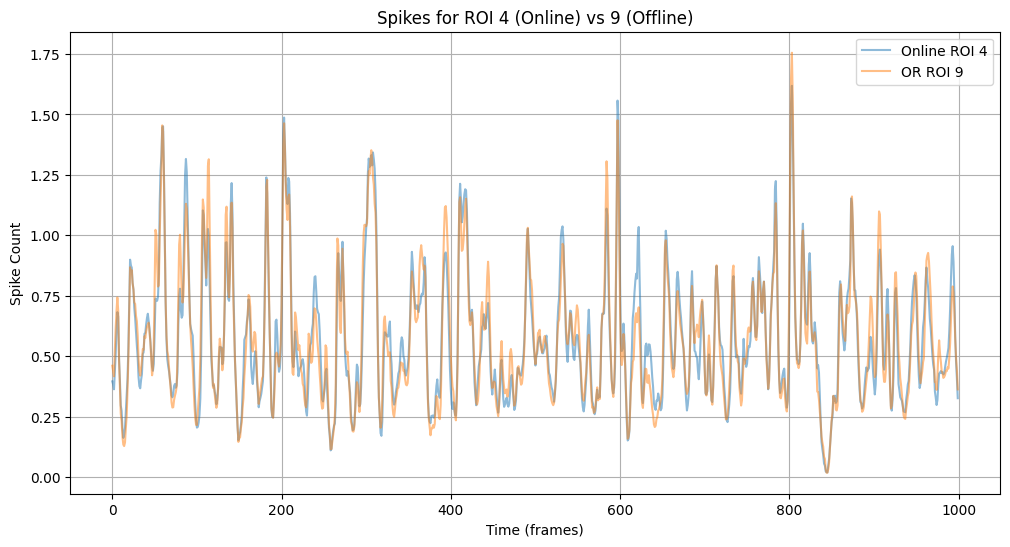

In [111]:

def compare_spikes_raw_data(online_roi_id, or_roi_id, t0 = 2000, t1=3000):
    offline_session_raw, online_session_raw = get_raw_response_dicts_for_session()
    offline_neuron_idx, online_neuron_idx = get_raw_responses_idx_from_rois(or_roi_id, online_roi_id, offline_session_raw, online_session_raw)
    print(f"Offline raw idx: {offline_neuron_idx}, Online raw idx: {online_neuron_idx}")

    # extract the spikes 
    online_spikes = online_session_raw["natural_spikes"][online_neuron_idx]
    or_spikes = offline_session_raw["natural_spikes"][offline_neuron_idx]

    print(np.corrcoef(online_spikes[~ np.isnan(online_spikes)], or_spikes[~ np.isnan(or_spikes)])[0, 1])

    # plot them overlaid in one figure
    plt.figure(figsize=(12, 6))

    print(online_spikes.shape, or_spikes.shape)
    plt.plot(online_spikes[t0:t1], label=f"Online ROI {online_roi_id}", alpha=0.5)
    plt.plot(or_spikes[t0:t1], label=f"OR ROI {or_roi_id}", alpha=0.5)

    plt.title(f"Spikes for ROI {online_roi_id} (Online) vs {or_roi_id} (Offline)")
    plt.xlabel("Time (frames)")
    plt.ylabel("Spike Count")
    plt.legend()
    plt.grid()
    plt.show()

online_roi_id = 4
or_roi_id = 9 
compare_spikes_raw_data(online_roi_id, or_roi_id)

Okay they seem to be veeeeery similar ... lets check online 41, 54 offline then the the MEIs 

Offline raw idx: 53, Online raw idx: 38
0.9599009645150935
(5036,) (5036,)


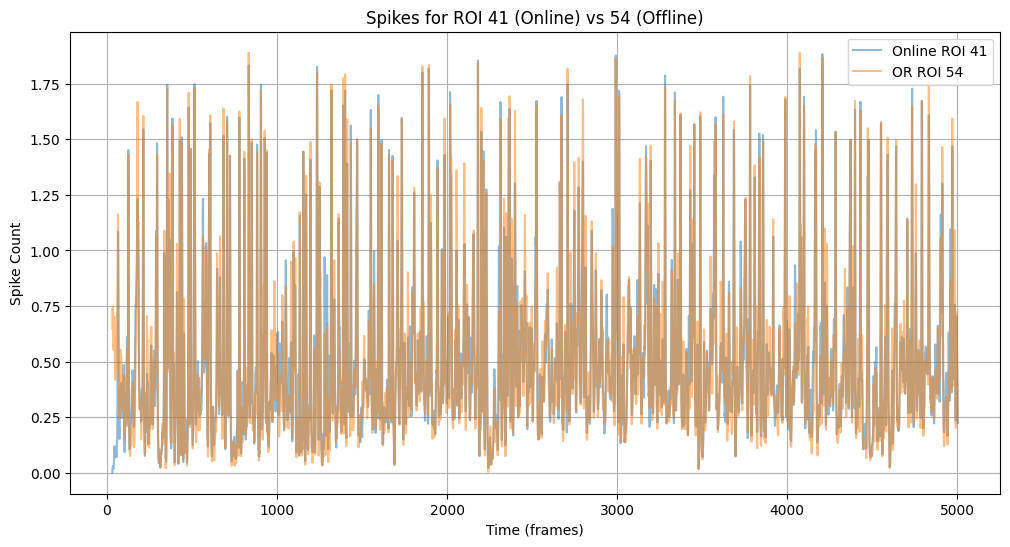

In [112]:
compare_spikes_raw_data(online_roi_id=41, or_roi_id=54,t0=0,t1=5036)

In [ ]:
compare_spikes_raw_data(online_roi_id=36, or_roi_id=48)

In [ ]:
# check if similar celltype assignment

def compare_celltypes(online_roi_id, or_roi_id):
    online_filt_session_dict = random_seed_mei_wrapper.neuron_data_dict['online_session_1_ventral1_20250717']
    neuron_idx = np.where(raw_session_dict["roi_ids"]== or_roi_id)[0].item()
    online_neuron_idx = np.where( online_raw_session_dict["roi_ids"]== online_roi_id)[0].item()

    # extract the spikes 
    online_celltype = online_raw_session_dict["group_assignment"][online_neuron_idx]
    or_celltype = raw_session_dict["group_assignment"][neuron_idx]
    
    confidence_online = online_raw_session_dict["group_confidences"][online_neuron_idx].max()
    confidence_or = raw_session_dict["group_confidences"][neuron_idx].max()

    print(f"Online Celltype: {online_celltype} confidence {confidence_online}\nOR Celltype: {or_celltype}, confidence {confidence_or}")


compare_celltypes(online_roi_id, or_roi_id)

Online Celltype: 22 confidence 0.20290709247776015
OR Celltype: 22, confidence 0.38847899436950684


In [203]:
compare_celltypes(online_roi_id=41, or_roi_id=54)

Online Celltype: 17 confidence 0.5223695421015072
OR Celltype: 17, confidence 0.30858272314071655


# mei similarity

look at online 41 offline 54 because they are both not filtered

In [ ]:
# # save or load data
# import pickle
# path_online_session_dict = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/validate_online_analysis/online_session_dict_raw.pkl"

# with open(path_online_session_dict, "wb") as f:
#     pickle.dump(random_seed_mei_wrapper.session_dict_raw, f)



In [36]:
from simulations.loop_components.model_to_stimulus import (load_pretrained_model,
                                                           generate_optimization_components,
                                                           generate_mei,
                                                           decompose_mei,
                                                           Center)
from openretina.utils.plotting import play_stimulus, plot_stimulus_composition


In [37]:
def load_offline_model():
    full_model_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/models/full/checkpoints/epoch=51_val_correlation=0.251.ckpt"

    or_model = load_pretrained_model(full_model_path,)
    # center readout 
    center = Center(target_mean=0.0)
    center(or_model)
    return or_model

def get_online_model(random_seed_mei_wrapper):
    model = random_seed_mei_wrapper.model
    center = Center(target_mean=0.0)
    center(model)
    return model




ResponsesTrainTestSplit(train=array([[1.34623678, 1.35421051, 1.36589939, ..., 2.73988843, 2.71544589,
        2.69131784],
       [1.2496642 , 1.26686626, 1.28078302, ..., 4.45432212, 4.61620357,
        4.54840001],
       [3.02913495, 3.22095136, 3.41875478, ..., 1.24188197, 1.21395909,
        1.20309055],
       ...,
       [2.30994611, 2.17883638, 2.0072421 , ..., 1.71422502, 1.68419875,
        1.65225478],
       [0.68746305, 0.70969828, 0.76480524, ..., 0.56086209, 0.53772087,
        0.52799814],
       [0.57241498, 0.54320622, 0.52109731, ..., 0.65929607, 0.61020711,
        0.56900985]]), test_dict={'test': array([[1.80479043, 1.81124428, 1.80358022, ..., 1.33832567, 1.37061774,
        1.40272591],
       [2.45108448, 2.34010068, 2.21523326, ..., 1.24052827, 1.23567369,
        1.23316029],
       [2.34597809, 2.47886333, 2.58313306, ..., 0.92249865, 0.92785062,
        0.94048307],
       ...,
       [1.95449255, 1.90898828, 1.85261154, ..., 1.98285019, 2.06120222,
      

In [101]:
def get_online_offline_mei_form_roi_ids(offline_roi,online_roi,offline_model,online_model,set_eval = False):


    offline_neuron_data_dict, online_neuron_data_dict = get_neuron_data_dicts_for_session()
    offline_neuron_idx, online_neuron_idx = get_readout_idx_from_rois(offline_roi, online_roi, offline_neuron_data_dict, online_neuron_data_dict)

    stimulus_postprocessor_list, response_reducer = generate_optimization_components(
        reducer_start= params["reducer_start"],
        reducer_length=params["reducer_length"],
    )

    if set_eval:
        offline_model.eval()
        online_model.eval()
    else:
        offline_model.train()
        online_model.train()


    offline_roi__mei = generate_mei(offline_model,
                new_session_id=OFFLINE_SESSION_ID,
                stimulus_postprocessor_list=stimulus_postprocessor_list,
                response_reducer=response_reducer,
                neuron_id=offline_neuron_idx,
                lr = params["lr"],
                max_iterations=params["max_iteration"],
                )
    online_roi__mei = generate_mei(online_model,
                new_session_id=ONLINE_SESSION_ID,
                stimulus_postprocessor_list=stimulus_postprocessor_list,
                response_reducer=response_reducer,
                neuron_id=online_neuron_idx,
                lr = params["lr"],
                max_iterations=params["max_iteration"],
                )



    return offline_roi__mei,online_roi__mei,offline_neuron_idx, online_neuron_idx

def find_closest_offline_roi_id(online_roi_id):
    raw_session_dict, online_raw_session_dict = get_raw_response_dicts_for_session()
    online_neuron_idx_raw = np.where( online_raw_session_dict["roi_ids"]== online_roi_id)[0].item()
    online_spikes = online_raw_session_dict["natural_spikes"][online_neuron_idx_raw]

    max_corr = -1
    best_offline_roi_id = None

    for or_roi_id in raw_session_dict["roi_ids"]:
        neuron_idx = np.where(raw_session_dict["roi_ids"]== or_roi_id)[0].item()
        or_spikes = raw_session_dict["natural_spikes"][neuron_idx]
        corr = np.corrcoef(online_spikes[~ np.isnan(online_spikes)], or_spikes[~ np.isnan(or_spikes)])[0, 1]
        if corr > max_corr:
            max_corr = corr
            best_offline_roi_id = or_roi_id

    return best_offline_roi_id, max_corr

def compare_highlighted_masks(offline_roi_id,
                              online_roi_id):
    fig,ax = plt.subplots(1,2,figsize=(10, 5))

    raw_session_dict, online_raw_session_dict = get_raw_response_dicts_for_session()
    online_mask = online_raw_session_dict["roi_mask"]
    offline_mask = raw_session_dict["roi_mask"]
    show_highlighted_mask(offline_mask, offline_roi_id, ax[0])
    show_highlighted_mask(online_mask, online_roi_id, ax[1])
    ax[0].set_title(f"Offline ROI ID: {offline_roi_id}")
    ax[1].set_title(f"Online ROI ID: {online_roi_id}")
    plt.show()

def mei_and_plot_decomposition(offline_roi_id,online_roi_id,set_eval = False,tesset_responses= True, mei_responses = True):
    offline_model = load_offline_model()
    online_model = get_online_model(random_seed_mei_wrapper)
    offline_mei,online_mei,offline_idx,online_idx = get_online_offline_mei_form_roi_ids(offline_roi_id,online_roi_id,offline_model,online_model,set_eval=set_eval)
    fig,ax = plt.subplots(2,4,figsize=(20, 10))
    plot_stimulus_composition(offline_mei,ax[0,0],ax[0,1],ax[0,2],)
    plot_stimulus_composition(online_mei,ax[1,0],ax[1,1],ax[1,2],)
    ax[0,0].set_title(f"Offline ROI ID: {offline_roi_id} (readout idx {offline_idx}) Temporal")
    ax[1,0].set_title(f"Online ROI ID: {online_roi_id} (readout idx {online_idx}) Temporal")

    # responses
    if tesset_responses:
        offline_pred, online_pred = get_neuron_testmovie_predictions(offline_idx,online_idx,offline_model,online_model)
        ax[0,3].plot(offline_pred,label = "Offline Prediction")
        ax[0,3].plot(online_pred,label = "Online Prediction")
        ax[0,3].legend()
        correl = np.corrcoef(offline_pred,online_pred)[0,1]
        ax[0,3].set_title(f"testset predictions corr: {correl:.3f}")

    # plot responses of each model to each mei in the last column
    if mei_responses:
        offline_pred_offline_mei, online_pred_offline_mei = get_models_responses(offline_mei.unsqueeze(0),offline_idx,online_idx,offline_model,online_model)
        offline_pred_online_mei, online_pred_online_mei = get_models_responses(online_mei.unsqueeze(0),offline_idx,online_idx,offline_model,online_model)
        ax[1,3].plot(offline_pred_offline_mei,label = "Offline Model on Offline MEI")
        ax[1,3].plot(online_pred_offline_mei,label = "Online Model on Offline MEI")
        ax[1,3].plot(offline_pred_online_mei,label = "Offline Model on Online MEI")
        ax[1,3].plot(online_pred_online_mei,label = "Online Model on Online MEI")
        ax[1,3].legend()


    
        
def check_if_both_rois_in_readout(offline_roi_id,online_roi_id):
    offline_neuron_data_dict, online_neuron_data_dict = get_neuron_data_dicts_for_session()
    offline_rois_in_readout = offline_neuron_data_dict.session_kwargs["roi_ids"]
    online_rois_in_readout = online_neuron_data_dict.session_kwargs["roi_ids"]


    in_both = offline_roi_id in offline_rois_in_readout and online_roi_id in online_rois_in_readout

    return in_both,online_rois_in_readout


def get_models_responses(tensor,offline_readout_idx, online_readout_idx,offline_model,online_model):
    with torch.no_grad():
        offline_pred = offline_model.forward(tensor,data_key = OFFLINE_SESSION_ID)[0,:,offline_readout_idx].detach().cpu().numpy()
        online_pred = online_model.forward(tensor,data_key=ONLINE_SESSION_ID)[0,:,online_readout_idx].detach().cpu().numpy()
    return offline_pred, online_pred

def get_neuron_testmovie_predictions(offline_readout_idx, online_readout_idx,offline_model,online_model):
    movie_tensor = torch.tensor(movies_dict.test_movie,device = offline_model.device,dtype=torch.float32).unsqueeze(0)
    offline_pred, online_pred = get_models_responses(movie_tensor,offline_readout_idx, online_readout_idx,offline_model,online_model)
    return offline_pred, online_pred
    
def wrapper_compare_mei(online_roi_id,set_eval = False):
    offline_roi_id, corr = find_closest_offline_roi_id(online_roi_id)

    in_both, in_readout = check_if_both_rois_in_readout(offline_roi_id,online_roi_id)
    if not in_both:
        print(f"Warning: One of the ROIs is not in both readouts. ROI in online : {in_readout}")
        return None


    print(f"Closest offline ROI ID: {offline_roi_id} with correlation {corr}")
    compare_highlighted_masks(offline_roi_id,online_roi_id)
    mei_and_plot_decomposition(offline_roi_id,online_roi_id,set_eval=set_eval)


Closest offline ROI ID: 54 with correlation 0.9599009645150935


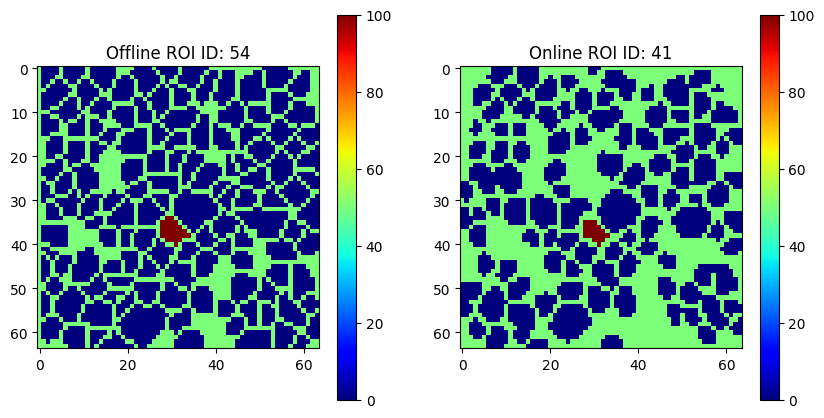

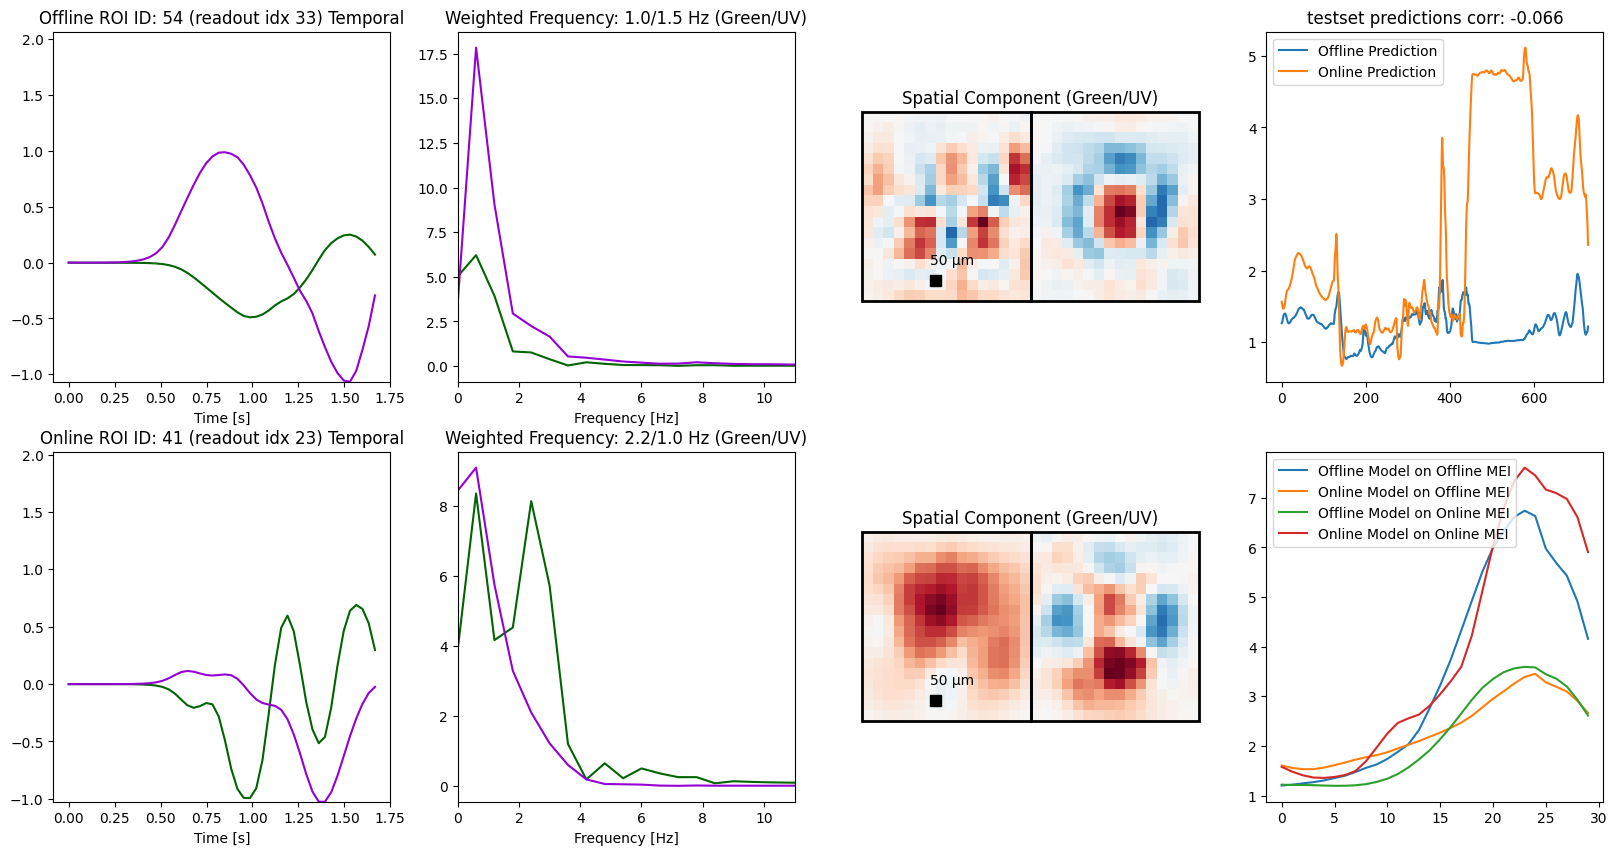

In [102]:
wrapper_compare_mei(online_roi_id=41,set_eval=True)

Closest offline ROI ID: 107 with correlation 0.9971865268305885


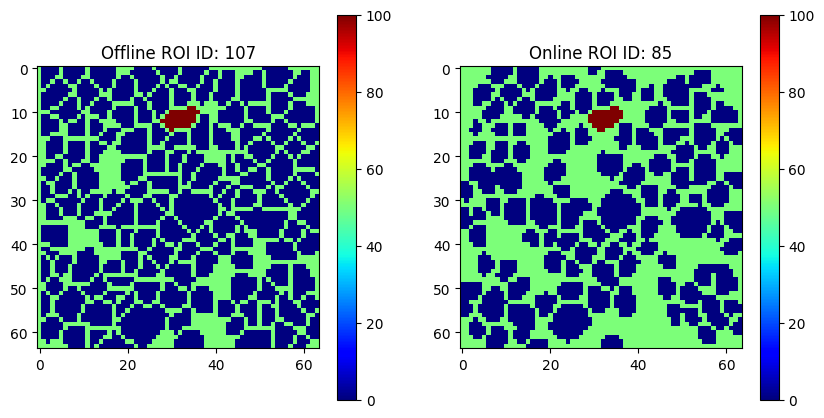

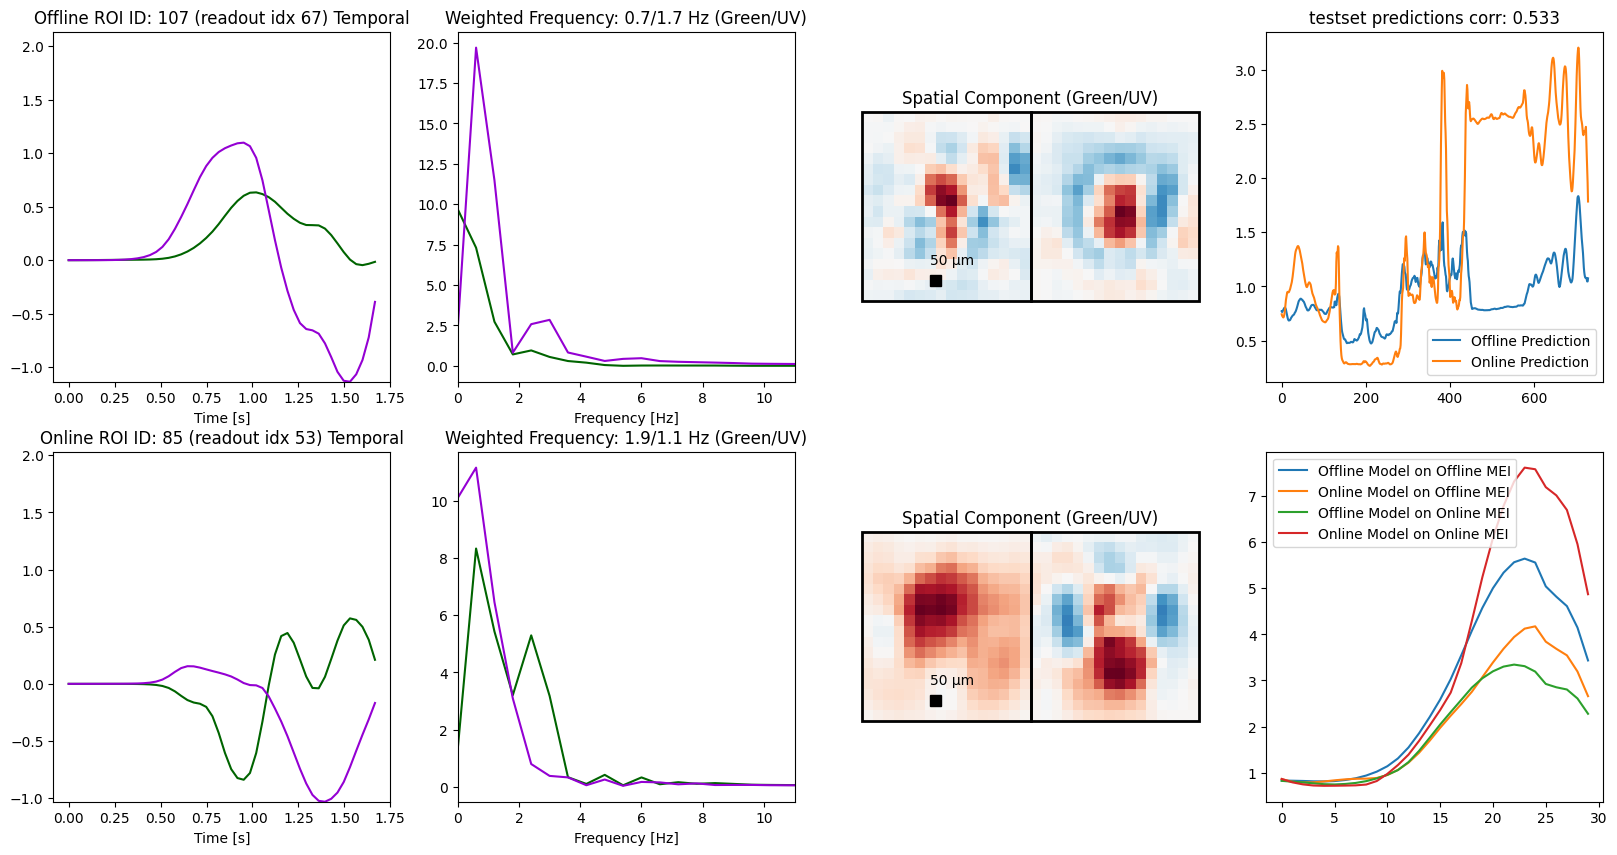

In [103]:
wrapper_compare_mei(online_roi_id=85,set_eval=True)

This seems to be okay despite the occasional sign flip in the offline mode. Sign flips are irrelevant for the reconstruction. 

Closest offline ROI ID: 7 with correlation 0.9782925201486201


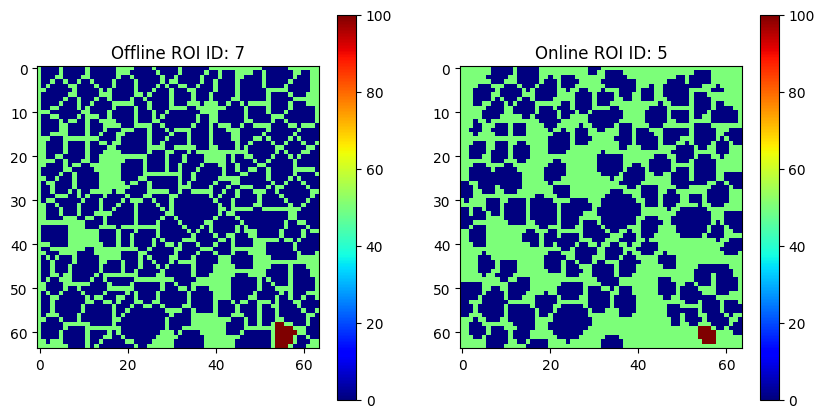

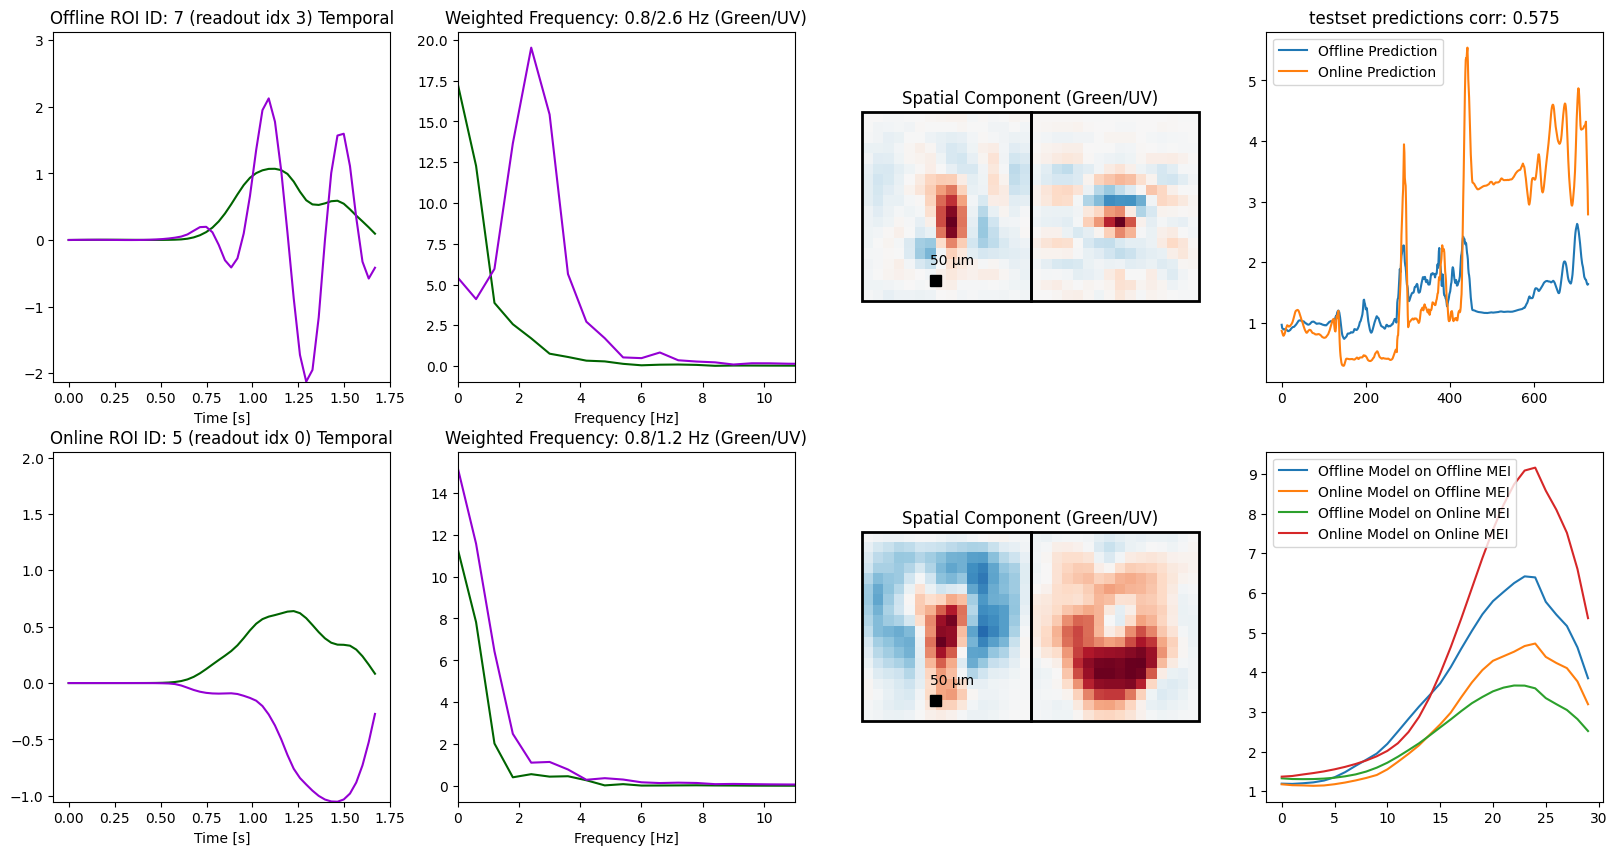

In [104]:
wrapper_compare_mei(online_roi_id=5,set_eval=True)

Closest offline ROI ID: 14 with correlation 0.9945034181921929


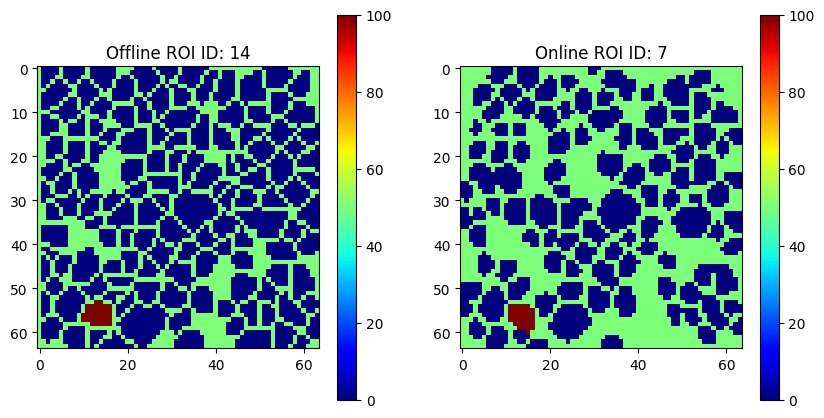

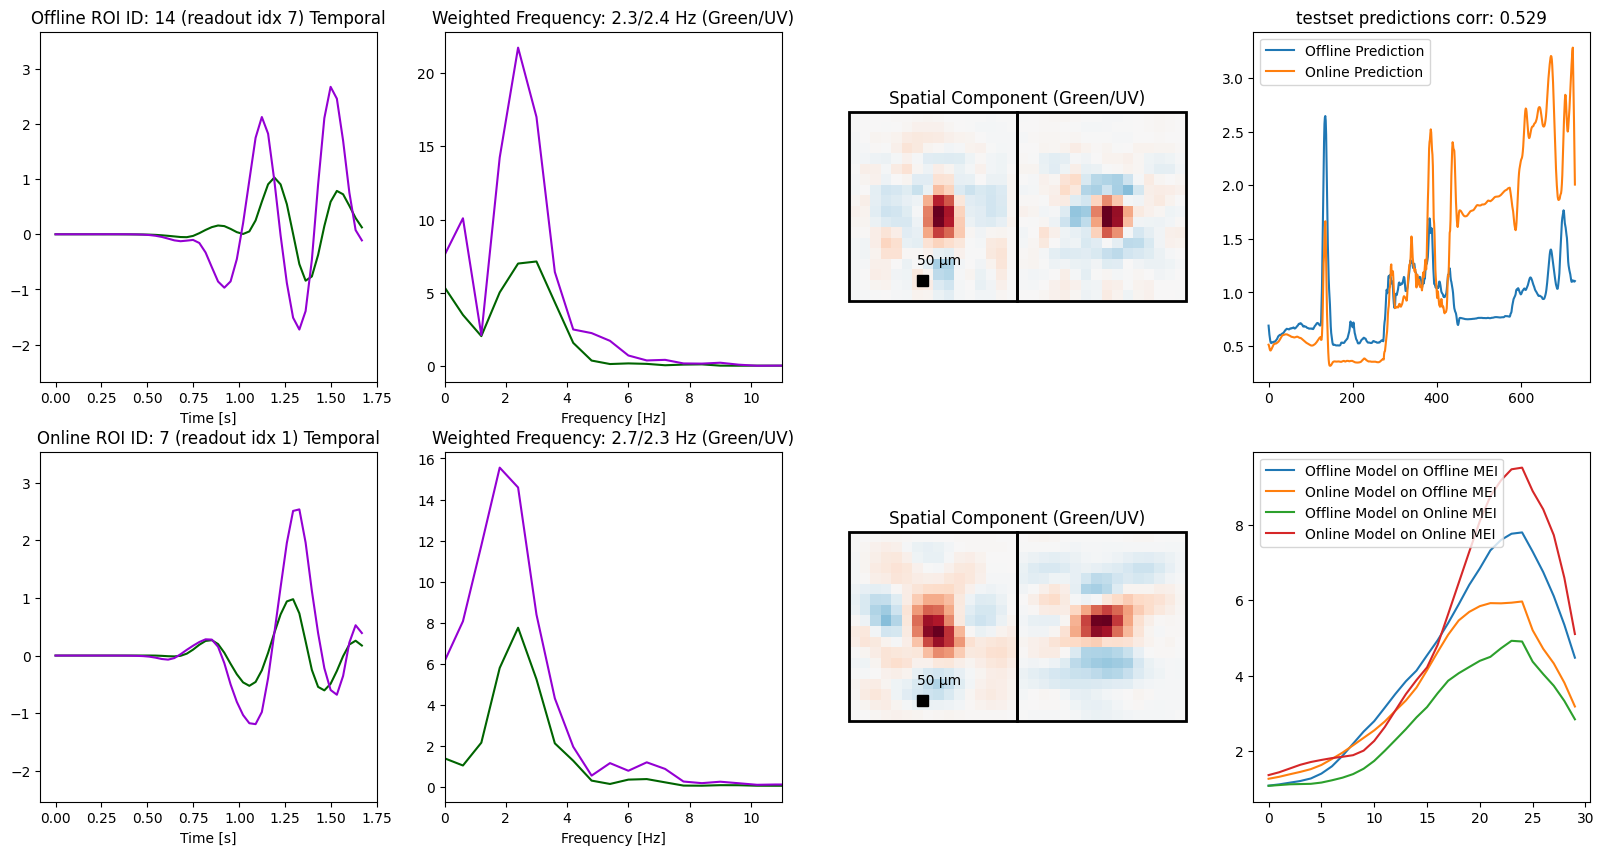

In [105]:
wrapper_compare_mei(online_roi_id=7,set_eval=True)

In [50]:
wrapper_compare_mei(online_roi_id=14,set_eval=True)

Closest offline ROI ID: 17 with correlation 0.9059758173395567


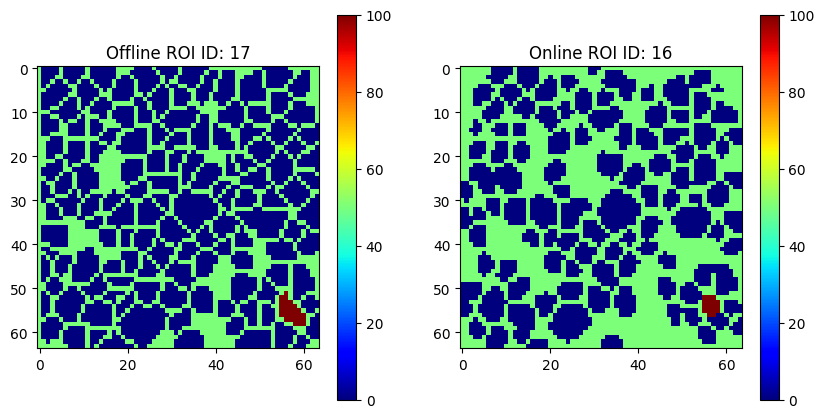

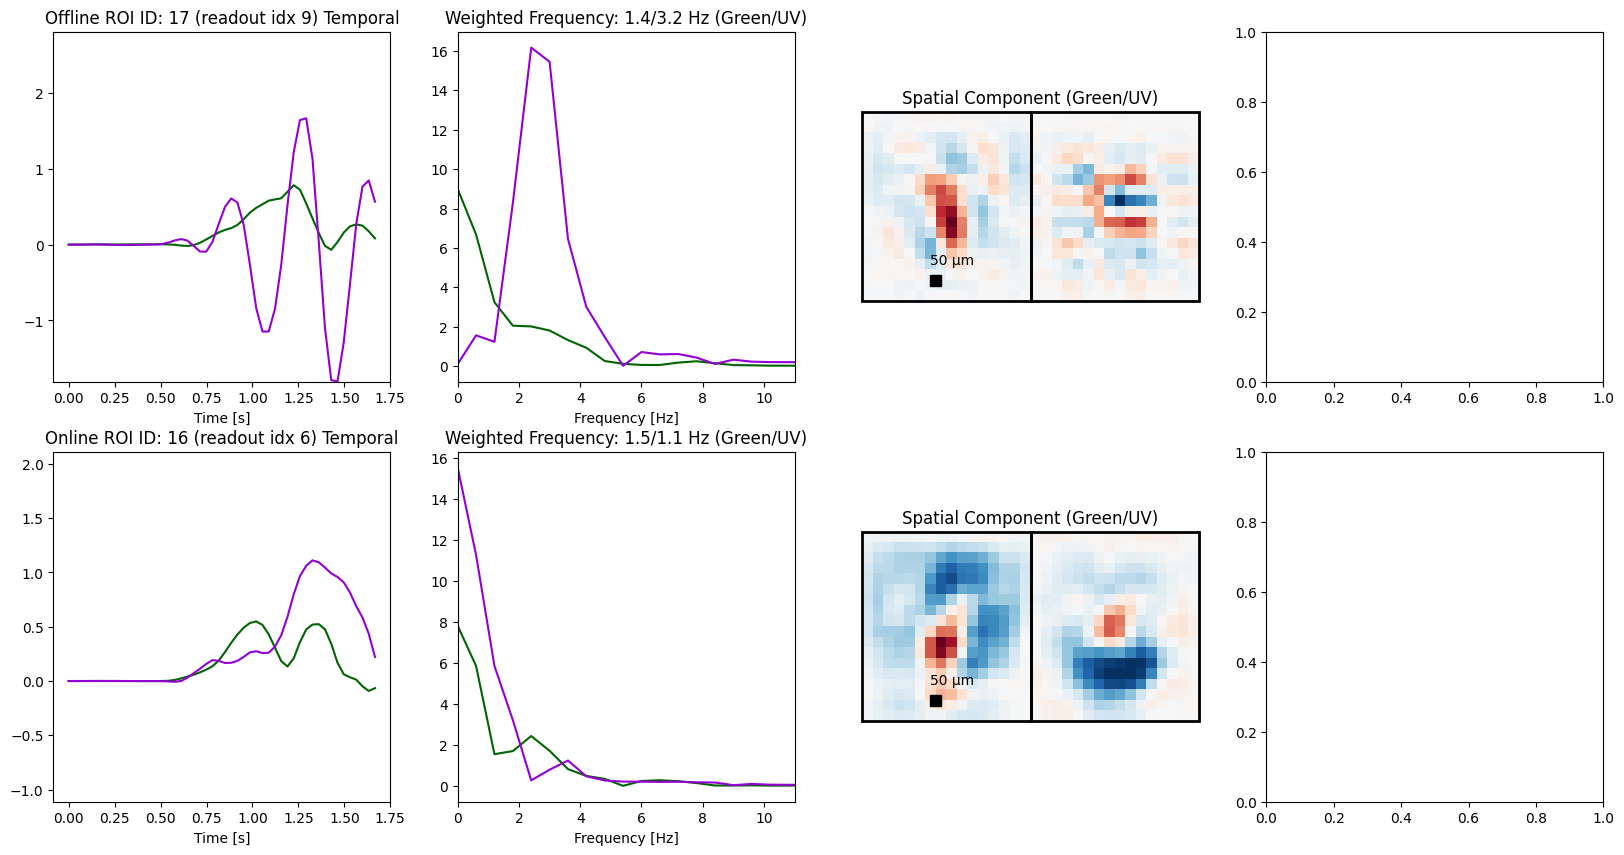

In [ ]:

wrapper_compare_mei(online_roi_id=16,set_eval=True)

Closest offline ROI ID: 47 with correlation 0.963730078231918


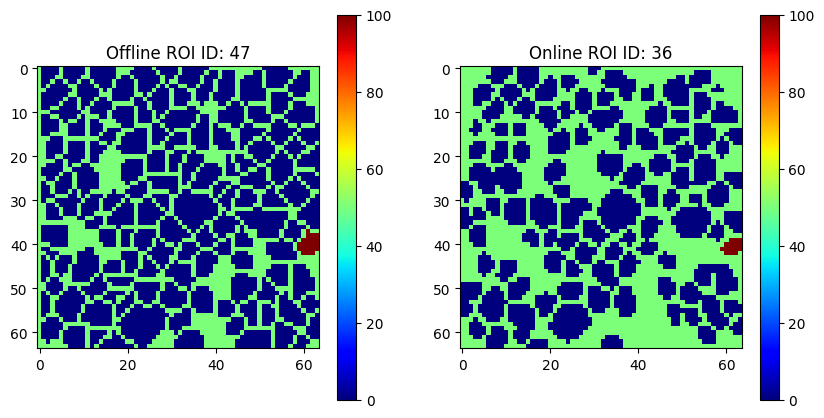

In [ ]:
wrapper_compare_mei(online_roi_id=36,set_eval=True)

Closest offline ROI ID: 49 with correlation 0.9926755323925422


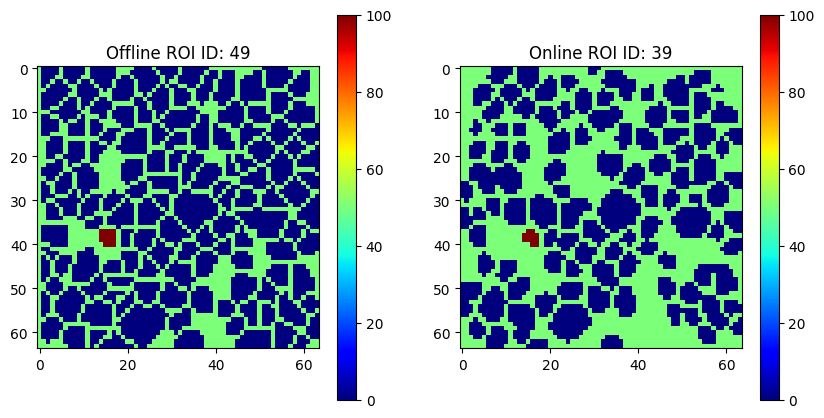

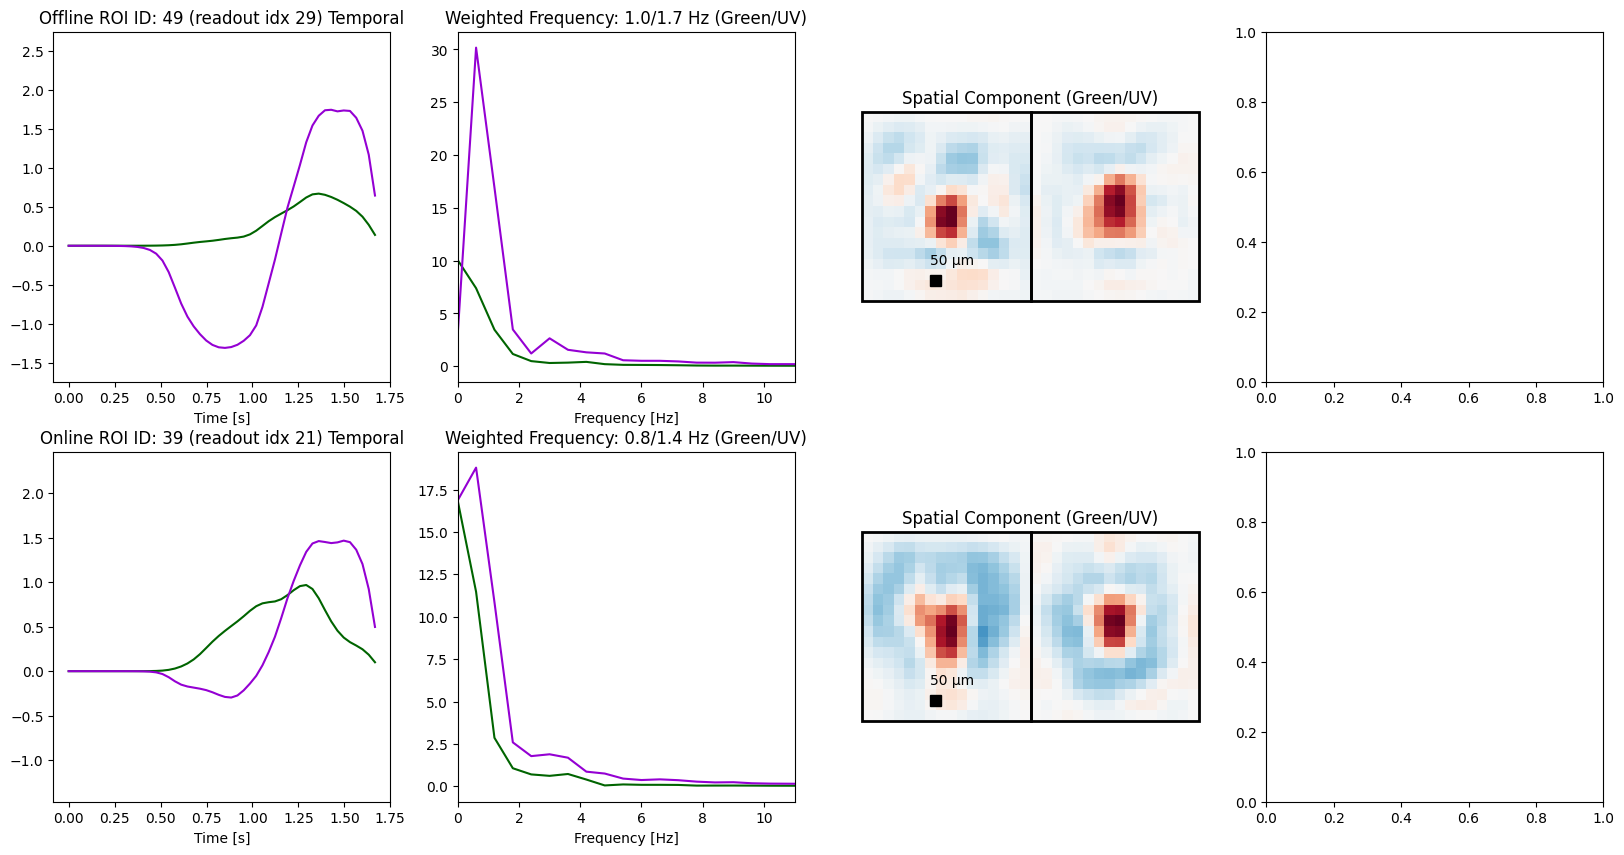

In [70]:
wrapper_compare_mei(online_roi_id=39,set_eval=True)

Closest offline ROI ID: 60 with correlation 0.9776204600057727


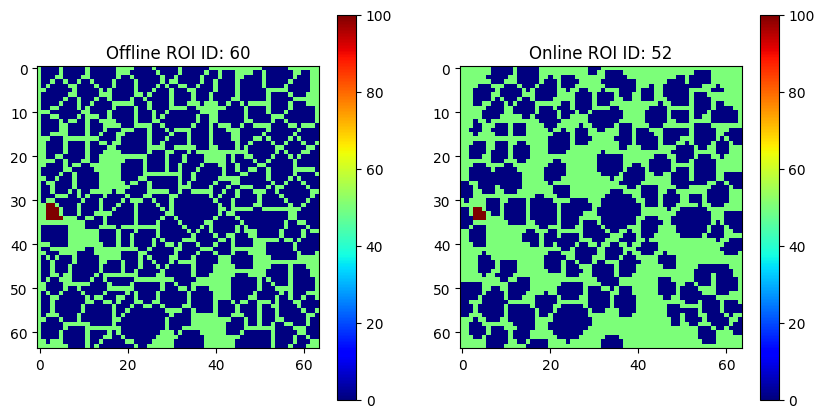

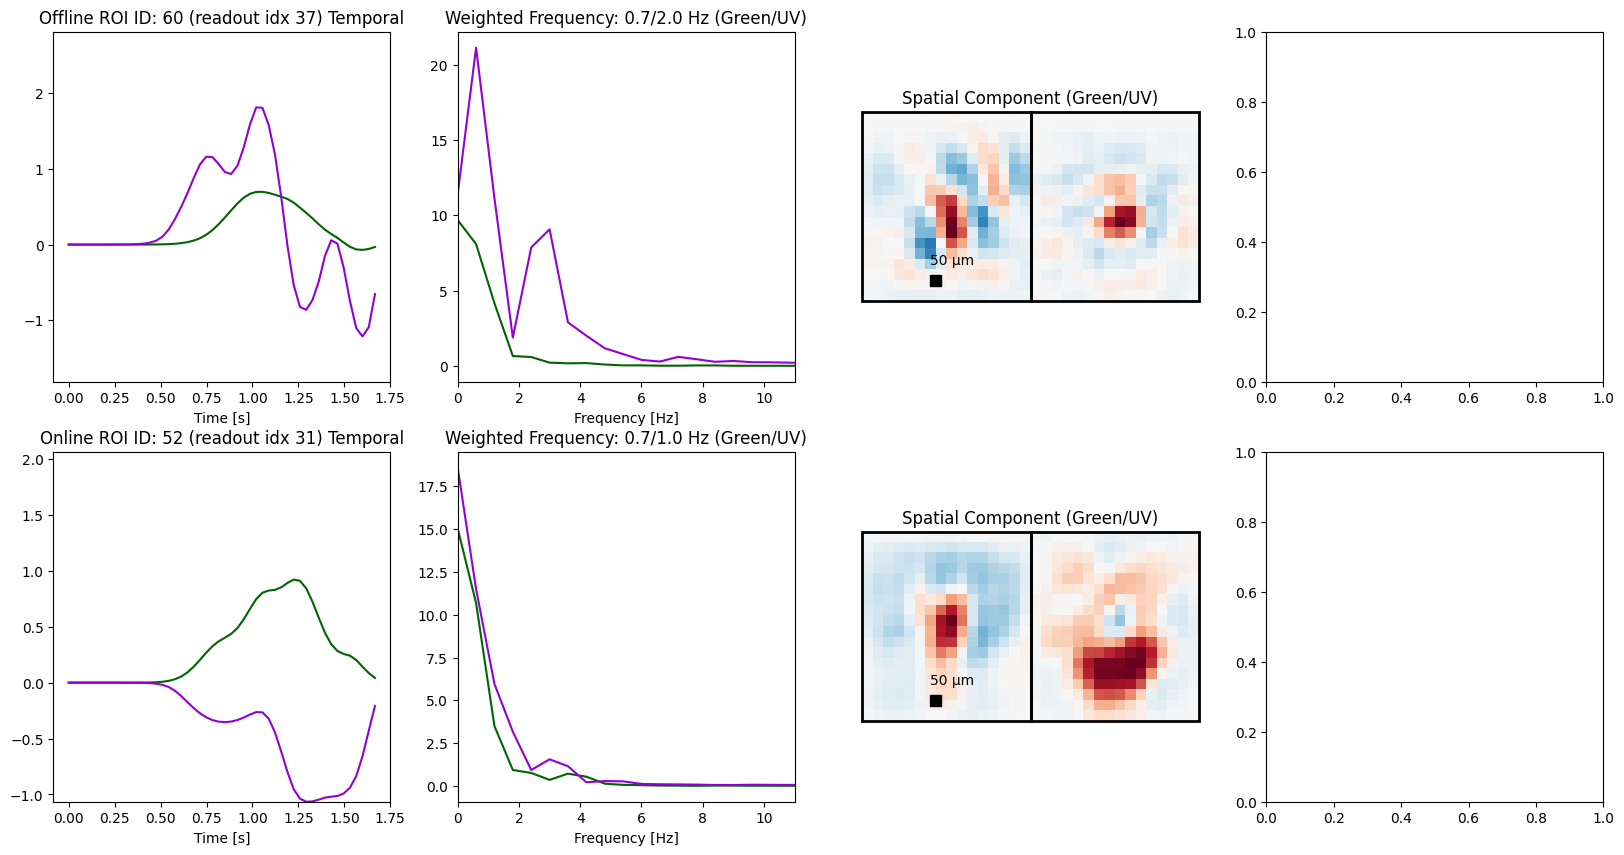

In [71]:
wrapper_compare_mei(online_roi_id=52,set_eval=True)